# 난지 하루 시간대별 혼잡도 그래프

이 노트는 `nanji_test_predictions.csv`의 최종 Ridge 예측값 `weather_only_final_prediction`을 사용해,
특정 하루의 시간대별 혼잡도를 그래프로 표현합니다.

- `TOTAL_CAPACITY`를 넣으면 실제 점유율(0~100%)
- 비워두면 해당 날짜의 최대 예측값을 100으로 둔 상대 혼잡도

로 그립니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
NOTE_DIR = Path.cwd()
PREDICTION_PATH = NOTE_DIR / 'nanji_outputs' / 'nanji_test_predictions.csv'
MODEL_COLUMN = 'weather_only_final_prediction'

# 원하는 날짜를 여기서 바꾸면 됩니다.
TARGET_DATE = '2025-08-10'

# 총 주차면 수를 알고 있으면 숫자를 넣고, 모르면 None으로 둡니다.
TOTAL_CAPACITY = 618

OUTPUT_PATH = NOTE_DIR / 'nanji_outputs' / f'nanji_daily_congestion_{TARGET_DATE}.png'

In [3]:
df = pd.read_csv(PREDICTION_PATH, parse_dates=['datetime'])
daily = df[df['datetime'].dt.date == pd.to_datetime(TARGET_DATE).date()].copy()

if daily.empty:
    raise ValueError(f'No prediction rows found for date: {TARGET_DATE}')
if MODEL_COLUMN not in daily.columns:
    raise KeyError(f'Model column not found: {MODEL_COLUMN}')

daily['hour'] = daily['datetime'].dt.hour
daily = daily.sort_values('datetime').reset_index(drop=True)

if TOTAL_CAPACITY is not None:
    daily['predicted_congestion'] = (daily[MODEL_COLUMN] / TOTAL_CAPACITY * 100).clip(lower=0, upper=100)
    daily['actual_congestion'] = (daily['estimated_active_cars'] / TOTAL_CAPACITY * 100).clip(lower=0, upper=100)
    y_label = 'Congestion / Occupancy (%)'
    subtitle = f'Total capacity = {TOTAL_CAPACITY:g}'
else:
    peak_value = max(float(daily[MODEL_COLUMN].max()), 1.0)
    daily['predicted_congestion'] = daily[MODEL_COLUMN] / peak_value * 100
    daily['actual_congestion'] = daily['estimated_active_cars'] / peak_value * 100
    y_label = 'Relative Congestion Index (daily max prediction = 100)'
    subtitle = 'Total capacity not provided, so this is a relative index'

daily[['datetime', 'hour', 'estimated_active_cars', MODEL_COLUMN, 'predicted_congestion', 'actual_congestion']].head()

,datetime,hour,estimated_active_cars,weather_only_final_prediction,predicted_congestion,actual_congestion
0,2025-08-10 00:00:00,0,0.0,0.0,0.0,0.0
1,2025-08-10 01:00:00,1,0.0,0.0,0.0,0.0
2,2025-08-10 02:00:00,2,0.0,0.0,0.0,0.0
3,2025-08-10 03:00:00,3,0.0,0.0,0.0,0.0
4,2025-08-10 04:00:00,4,0.0,0.0,0.0,0.0


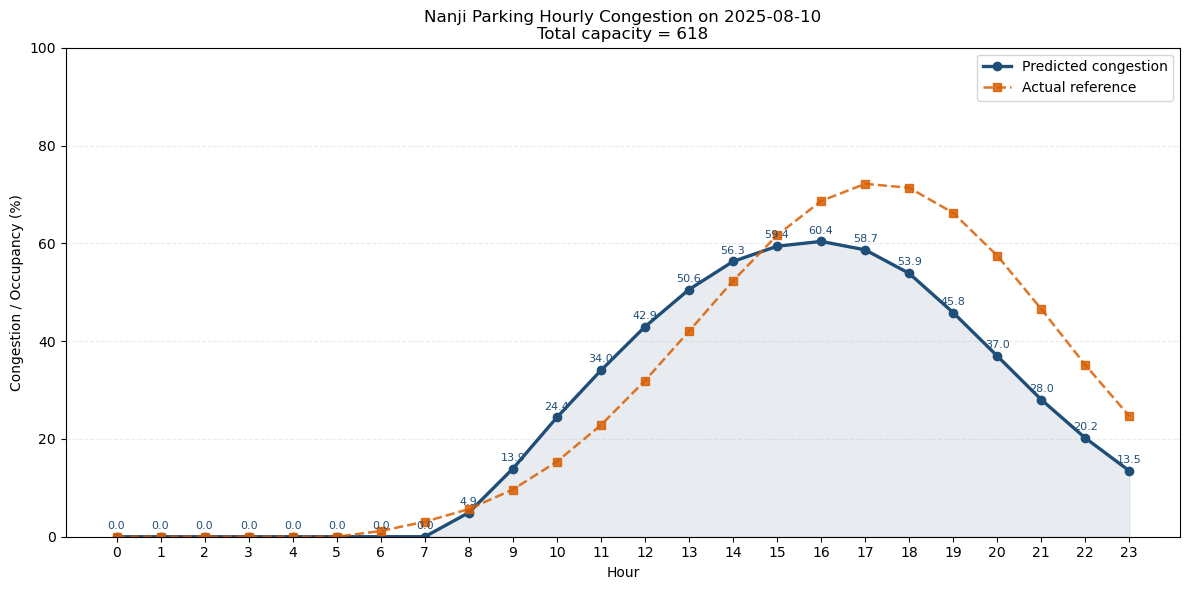

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    daily['hour'],
    daily['predicted_congestion'],
    marker='o',
    linewidth=2.4,
    color='#1f4e79',
    label='Predicted congestion',
)
ax.plot(
    daily['hour'],
    daily['actual_congestion'],
    marker='s',
    linewidth=1.8,
    linestyle='--',
    color='#d95f02',
    alpha=0.85,
    label='Actual reference',
)
ax.fill_between(
    daily['hour'],
    daily['predicted_congestion'],
    color='#1f4e79',
    alpha=0.10,
)

ax.set_title(f'Nanji Parking Hourly Congestion on {TARGET_DATE}\n{subtitle}')
ax.set_xlabel('Hour')
ax.set_ylabel(y_label)
ax.set_xticks(range(24))
ax.set_ylim(0, max(100, float(daily['predicted_congestion'].max()) * 1.08))
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(frameon=True)

for row in daily.itertuples(index=False):
    ax.text(
        row.hour,
        row.predicted_congestion + 1.2,
        f'{row.predicted_congestion:.1f}',
        ha='center',
        va='bottom',
        fontsize=8,
        color='#1f4e79',
    )

plt.tight_layout()
plt.show()

In [5]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches='tight')
print('saved chart:', OUTPUT_PATH)

if TOTAL_CAPACITY is None:
    print('note: total capacity was not provided, so this image is a relative congestion index, not a true occupancy percentage.')
else:
    print('note: this image uses the provided total capacity and shows occupancy percentage.')

saved chart: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_outputs/nanji_daily_congestion_2025-08-10.png
note: this image uses the provided total capacity and shows occupancy percentage.
